## Introduction
Ce notebook sert à visualiser les différents résultats issus du tracking

In [48]:
import json
from pathlib import Path

import numpy as np
import sys
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [49]:
project_root = Path("..").resolve()
sys.path.append(str(project_root))

from Calibration.Parameters import CHAMBERS_COLORS

In [50]:

project_root = Path("..")  # remonte d'un dossier depuis Data_analysis
project_root = project_root.resolve()
tracking_files = project_root / "Data" 
tracking_file = project_root / "Data" / "Experiment_4" / "Video" / "Labyrinths" / "Labyrinthe_A" / "Labyrinthe_A_top_tracking.json"

In [51]:
tracking_video = project_root / "Data" / "Experiment_4" / "Video" / "Labyrinths" / "Labyrinthe_A" / "Labyrinthe_A_bottom.mp4"
cap = cv2.VideoCapture(str(tracking_video))
ret, frame = cap.read()
if not ret:
    raise ValueError("La vidéo n'a pas pu être ouverte")
video_height, video_width = frame.shape[:2]
cap.release()

print(f"Taille vidéo : {video_width} x {video_height}")

Taille vidéo : 888 x 930


In [52]:
mask_path = project_root / "Calibration" / "Maze_pictures" / "Maze_mask_top_painted.png"
mask = cv2.imread(str(mask_path))
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

mask_resized = cv2.resize(
    mask,
    (video_width, video_height),
    interpolation=cv2.INTER_NEAREST
)

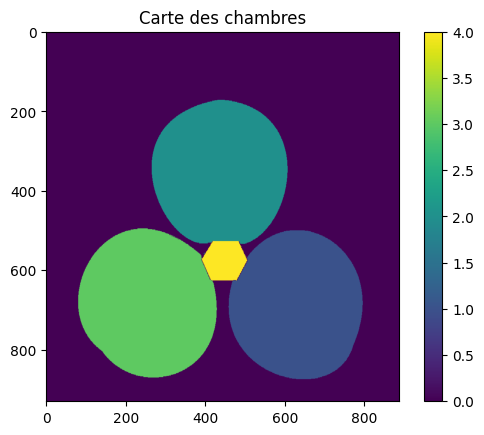

In [53]:
COLOR_MAP = {
    "Red": (255,0,0),
    "Green": (0,255,0),
    "Blue": (0,0,255),
    "White": (255,255,255)
}

CHAMBERS_RGB = {
    chamber: COLOR_MAP[color]
    for chamber, color in CHAMBERS_COLORS.items()
}

chamber_index = {
    "Chambre_1": 1,
    "Chambre_3": 2,
    "Chambre_2": 3,
    "Decision_zone": 4
}

chamber_map = np.zeros(mask_resized.shape[:2], dtype=int)

for chamber, rgb in CHAMBERS_RGB.items():

    mask_pixels = np.all(mask_resized == rgb, axis=2)

    chamber_map[mask_pixels] = chamber_index[chamber]

plt.imshow(chamber_map)
plt.title("Carte des chambres")
plt.colorbar()

## Zones de visites

In [54]:
with open(tracking_file) as f:
    data = json.load(f)

fps = data["fps"]
tracking = data["tracking"]

In [55]:
df = pd.DataFrame(tracking)

df["x"] = df["position"].apply(lambda p: p["x"] if p else None)
df["y"] = df["position"].apply(lambda p: p["y"] if p else None)

df = df.drop(columns="position")

df.head()

,frame,time_sec,detected,distance_px,speed_px_per_sec,x,y
0,0,0.000000,True,0.000000,0.000000,313,339
1,1,0.166667,True,3.162278,18.973666,312,336
2,2,0.333333,True,1.414214,8.485281,313,337
3,3,0.500000,True,1.000000,6.000000,313,338
4,4,0.666667,True,1.000000,6.000000,313,339


In [56]:
df["x_int"] = df["x"].astype("Int64")
df["y_int"] = df["y"].astype("Int64")

height, width = chamber_map.shape

df["chamber_id"] = [
    chamber_map[y, x]
    if pd.notna(x) and pd.notna(y) and 0 <= x < width and 0 <= y < height
    else 0
    for x, y in zip(df["x_int"], df["y_int"])
]
inverse_map = {v:k for k,v in chamber_index.items()}
inverse_map[0] = "Outside"

df["chamber"] = df["chamber_id"].map(inverse_map)

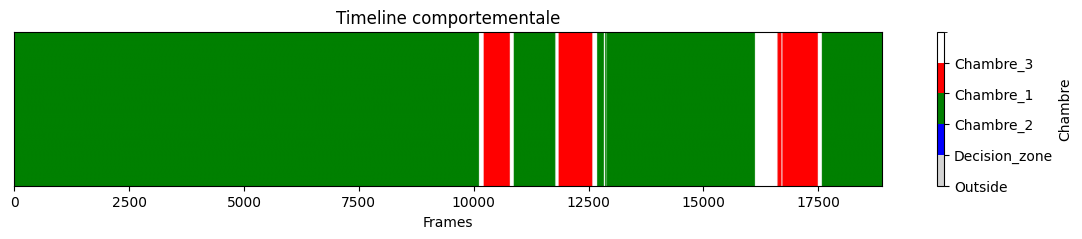

In [57]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Définir les couleurs pour chaque chambre
colors = {
    0: "lightgray",      # Outside
    3: "red",            # Chambre_3
    4: "white",          # Decision_zone
    2: "green",          # Chambre_2
    1: "blue"            # Chambre_1
}

# Créer une colormap et les bounds
cmap = mcolors.ListedColormap([colors[i] for i in sorted(colors.keys())])
bounds = np.array(sorted(colors.keys()) + [max(colors.keys())+1])
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Afficher la timeline
plt.figure(figsize=(14, 2))
plt.imshow(
    df["chamber_id"].values.reshape(1, -1),
    aspect="auto",
    cmap=cmap,
    norm=norm
)

# Enlever les ticks Y
plt.yticks([])

# Labels de la colorbar correspondant aux noms des chambres
cbar = plt.colorbar(ticks=list(colors.keys()), orientation="vertical")
cbar.ax.set_yticklabels([inverse_map[i] for i in sorted(colors.keys())])
cbar.set_label("Chambre")

plt.xlabel("Frames")
plt.title("Timeline comportementale")
plt.show()

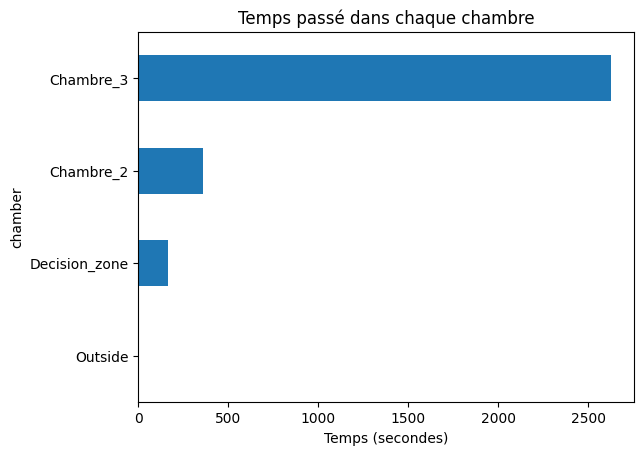

In [58]:
time_spent_sec = df.groupby("chamber").size() / fps

time_spent_sec.sort_values().plot.barh()

plt.xlabel("Temps (secondes)")
plt.title("Temps passé dans chaque chambre")

plt.show()

In [59]:
tracking_folder = project_root / "Data"

tracking_files = list(tracking_folder.rglob("*tracking.json"))

print(len(tracking_files), "fichiers trouvés")

15 fichiers trouvés
